# SALT3 - Downstream Evaluation

This notebook evaluates SALT3 models on 7 Vietnamese NLU benchmarks:

| Task | Dataset | Type | Classes | Metric |
|------|---------|------|---------|--------|
| PPPL | Vietnamese Wikipedia | Intrinsic (MLM) | — | Pseudo-Perplexity |
| Sentiment | UIT-VSFC | Sequence Classification | 3 | F1-weighted |
| NLI | XNLI-vi | Sequence Classification | 3 | Accuracy |
| Emotion | UIT-VSMEC | Sequence Classification | 7 | F1-macro |
| Toxicity | UIT-ViCTSD | Sequence Classification | 2 | F1-macro |
| POS Tagging | UD Vietnamese VTB | Token Classification | 18 UPOS | F1-macro |
| MRC | UIT-ViQuAD 2.0 | Extractive QA | — | SQuAD F1 / EM |

ViDeBERTa is intentionally excluded as a downstream baseline; it remains the target PLM for embedding initialization.

In [1]:
%%capture
!apt-get -qq install -y default-jre > /dev/null 2>&1
!pip install -U transformers accelerate datasets evaluate safetensors sentencepiece tokenizers pandas scikit-learn scipy matplotlib tqdm huggingface_hub py_vncorenlp

In [2]:
from pathlib import Path
import gc
import json
import random
import sys

import evaluate
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from datasets import Dataset, DatasetDict, load_dataset
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from transformers import (
    AutoConfig, AutoModelForMaskedLM, AutoModelForQuestionAnswering,
    AutoModelForSequenceClassification, AutoModelForTokenClassification,
    AutoTokenizer, DataCollatorForTokenClassification, DataCollatorWithPadding,
    DefaultDataCollator, Trainer, TrainingArguments,
)

plt.rcParams.update({'font.size': 11, 'figure.dpi': 120, 'figure.facecolor': 'white'})

try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as exc:
    print('Drive mount skipped:', exc)

PROJECT_ROOT = Path('/content/drive/MyDrive/SALT3') if Path('/content/drive/MyDrive').exists() else Path.cwd() / 'SALT3'
CODE_DIR = PROJECT_ROOT / 'code'
sys.path.insert(0, str(CODE_DIR))
sys.path.insert(0, '/content')

from salt3_common import (
    NeoBERTQuestionAnswering, NeoBERTSequenceClassifier, NeoBERTTokenClassifier,
    append_jsonl, bootstrap_ci, compute_regression_metrics, configure_environment,
    embedding_fingerprint, ensure_dir, get_last_checkpoint, load_model_safe,
    make_early_stopping, maybe_segment, paired_bootstrap_pvalue, read_jsonl,
    resolve_ref, segment_texts, set_seed, spearman_pearson,
    validate_model_artifact, write_json,
)

configure_environment()
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
print('Project root:', PROJECT_ROOT)

Mounted at /content/drive
Device: cuda
Project root: /content/drive/MyDrive/SALT3


In [4]:
EVAL_NAME = 'eval_123'
EVAL_DIR = ensure_dir(PROJECT_ROOT / 'eval' / EVAL_NAME)
RESULTS_JSONL = EVAL_DIR / 'downstream_results.jsonl'
SUMMARY_CSV = EVAL_DIR / 'downstream_summary.csv'
FORCE_RERUN = False
SEEDS = [42, 123, 456, 789, 1024]

# segment=True -> VnCoreNLP word-segment inputs (PhoBERT/ViDeBERTa expect segmented text).
# SALT3 (English wordpiece) and XLM-R (multilingual subword) use raw text.
MODEL_SPECS = {
    'SALT3-v5': {
        'kind': 'neobert',
        'ref': 'runs/new-v3-3m/final_model',  # point to your v5 CPT final_model
        'segment': False,
    },
    'PhoBERT-base-v2': {
        'kind': 'hf_sequence',
        'ref': 'vinai/phobert-base-v2',
        'segment': True,
    },
    'ViDeBERTa-base': {
        'kind': 'hf_sequence',
        'ref': 'Fsoft-AIC/videberta-base',  # same donor as SALT3 -> isolates SALT+CPT gain
        'segment': True,
    },
    'XLM-R-base': {
        'kind': 'hf_sequence',
        'ref': 'xlm-roberta-base',
        'segment': False,
    },
}

write_json(EVAL_DIR / 'eval_config.json', {
    'eval_name': EVAL_NAME,
    'models': MODEL_SPECS,
    'seeds': SEEDS,
})
print('Eval dir:', EVAL_DIR)
print('Results :', RESULTS_JSONL)

Eval dir: /content/drive/MyDrive/SALT3/eval/eval_123
Results : /content/drive/MyDrive/SALT3/eval/eval_123/downstream_results.jsonl


In [5]:
def model_path_from_spec(spec):
    ref = spec['ref']
    if spec['kind'].startswith('hf_') or ('/' in ref and not ref.startswith(('runs/', 'init/'))):
        return ref
    return resolve_ref(PROJECT_ROOT, ref)

def available_models():
    names = []
    for name, spec in MODEL_SPECS.items():
        path = model_path_from_spec(spec)
        if spec['kind'] == 'neobert':
            try:
                validate_model_artifact(path)
                names.append(name)
            except Exception as exc:
                print(f'Skip {name}: {exc}')
        else:
            names.append(name)
    return names

EVAL_MODELS = available_models()
print('Models to evaluate:', EVAL_MODELS)

def already_done(task, model_name, seed):
    if FORCE_RERUN:
        return False
    return any(
        row.get('task') == task and row.get('model') == model_name and row.get('seed') == seed
        for row in read_jsonl(RESULTS_JSONL)
    )

def save_result(task, model_name, seed, metrics):
    # record whether inputs were word-segmented so an accidental unsegmented
    # PhoBERT/ViDeBERTa run is visible in the results instead of silent
    spec = MODEL_SPECS.get(model_name, {})
    row = {'task': task, 'model': model_name, 'seed': seed,
           'segmented': bool(spec.get('segment', False)), **metrics}
    append_jsonl(RESULTS_JSONL, row)
    print('Saved result:', row)

def load_sequence_model(model_name, num_labels):
    spec = MODEL_SPECS[model_name]
    path = model_path_from_spec(spec)
    tokenizer = AutoTokenizer.from_pretrained(path, trust_remote_code=True)
    if spec['kind'] == 'neobert':
        base = load_model_safe(path, model_cls=AutoModelForMaskedLM, device='cpu')
        print('Base embedding fp:', embedding_fingerprint(base))
        model = NeoBERTSequenceClassifier(base, num_labels=num_labels).to(DEVICE)
    else:
        model = AutoModelForSequenceClassification.from_pretrained(
            path, num_labels=num_labels, trust_remote_code=True, ignore_mismatched_sizes=True
        ).to(DEVICE)
    return tokenizer, model

def load_token_classification_model(model_name, num_labels):
    spec = MODEL_SPECS[model_name]
    path = model_path_from_spec(spec)
    tokenizer = AutoTokenizer.from_pretrained(path, trust_remote_code=True)
    if spec['kind'] == 'neobert':
        base = load_model_safe(path, model_cls=AutoModelForMaskedLM, device='cpu')
        print('Base embedding fp:', embedding_fingerprint(base))
        model = NeoBERTTokenClassifier(base, num_labels=num_labels).to(DEVICE)
    else:
        model = AutoModelForTokenClassification.from_pretrained(
            path, num_labels=num_labels, trust_remote_code=True, ignore_mismatched_sizes=True
        ).to(DEVICE)
    return tokenizer, model

def compute_cls_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': float(accuracy_score(labels, preds)),
        'f1_macro': float(f1_score(labels, preds, average='macro')),
        'f1_weighted': float(f1_score(labels, preds, average='weighted')),
    }

def compute_token_cls_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    true_labels, true_preds = [], []
    for pred_row, label_row in zip(preds, labels):
        for p, l in zip(pred_row, label_row):
            if l != -100:
                true_labels.append(l)
                true_preds.append(p)
    return {
        'accuracy': float(accuracy_score(true_labels, true_preds)),
        'f1_macro': float(f1_score(true_labels, true_preds, average='macro')),
    }

_METRIC_KEYS = {'accuracy', 'f1_macro', 'f1_weighted', 'loss'}

def _save_artifacts(trainer, test_dataset, output_dir, task, model_name, seed, is_token_cls=False, record=True):
    """Score on the given split; if record, persist logs/preds/metrics. Always returns metrics.

    Callers pass the validation split for unrecorded selection (grid) runs and the
    test split only for recorded final runs, so HP selection never sees test data."""
    pred_output = trainer.predict(test_dataset)
    metrics = {}
    for k, v in pred_output.metrics.items():
        clean = k.replace('test_', '').replace('eval_', '')
        if clean in _METRIC_KEYS and isinstance(v, (int, float)):
            metrics[clean] = float(v)
    if not record:
        return metrics
    save_result(task, model_name, seed, metrics)
    write_json(output_dir / 'training_log.json', trainer.state.log_history)
    preds = np.argmax(pred_output.predictions, axis=-1)
    labels = pred_output.label_ids
    if is_token_cls:
        mask = labels != -100
        flat_preds = preds[mask].astype(np.int16)
        flat_labels = labels[mask].astype(np.int16)
        np.savez_compressed(str(output_dir / 'test_preds.npz'), preds=flat_preds, labels=flat_labels)
    else:
        np.savez_compressed(str(output_dir / 'test_preds.npz'), preds=preds, labels=labels)
    return metrics

def train_eval_token_classification(task, model_name, dataset, num_labels, label_col, epochs, lr, batch_size, seed, metric_for_best='f1_macro', patience=5, subdir=None, record=True):
    set_seed(seed)
    tokenizer, model = load_token_classification_model(model_name, num_labels)

    def tokenize_and_align(examples):
        if tokenizer.is_fast:
            tokenized = tokenizer(
                examples['tokens'], truncation=True, max_length=256,
                is_split_into_words=True,
            )
            all_labels = []
            for i, labels in enumerate(examples[label_col]):
                word_ids = tokenized.word_ids(batch_index=i)
                label_ids = []
                prev_word = None
                for wid in word_ids:
                    if wid is None:
                        label_ids.append(-100)
                    elif wid != prev_word:
                        label_ids.append(labels[wid])
                    else:
                        label_ids.append(-100)
                    prev_word = wid
                all_labels.append(label_ids)
            tokenized['labels'] = all_labels
            return tokenized
        # Slow tokenizer: tokenize each word separately and align manually
        max_len = 256
        cls_id = tokenizer.cls_token_id if tokenizer.cls_token_id is not None else tokenizer.bos_token_id
        sep_id = tokenizer.sep_token_id if tokenizer.sep_token_id is not None else tokenizer.eos_token_id
        all_input_ids, all_attention_mask, all_labels = [], [], []
        for words, labels in zip(examples['tokens'], examples[label_col]):
            input_ids = [cls_id]
            label_ids = [-100]
            for wid, (word, lbl) in enumerate(zip(words, labels)):
                word_toks = tokenizer.encode(word, add_special_tokens=False)
                if not word_toks:
                    word_toks = [tokenizer.unk_token_id]
                if len(input_ids) + len(word_toks) + 1 > max_len:
                    break
                for j, tid in enumerate(word_toks):
                    input_ids.append(tid)
                    label_ids.append(lbl if j == 0 else -100)
            input_ids.append(sep_id)
            label_ids.append(-100)
            all_input_ids.append(input_ids)
            all_attention_mask.append([1] * len(input_ids))
            all_labels.append(label_ids)
        return {'input_ids': all_input_ids, 'attention_mask': all_attention_mask, 'labels': all_labels}

    tokenized = dataset.map(tokenize_and_align, batched=True, remove_columns=dataset['train'].column_names)
    output_dir = EVAL_DIR / task / model_name.replace('/', '_') / (subdir or f'seed_{seed}')
    args = TrainingArguments(
        output_dir=str(output_dir), num_train_epochs=epochs, learning_rate=lr,
        per_device_train_batch_size=batch_size, per_device_eval_batch_size=batch_size * 2,
        weight_decay=0.01, warmup_ratio=0.1, eval_strategy='epoch', save_strategy='epoch',
        save_total_limit=1, load_best_model_at_end=True, metric_for_best_model=metric_for_best,
        greater_is_better=True, bf16=torch.cuda.is_bf16_supported() if torch.cuda.is_available() else False,
        fp16=not torch.cuda.is_bf16_supported() if torch.cuda.is_available() else False,
        tf32=torch.cuda.is_available(), report_to='none', seed=seed,
    )
    trainer = Trainer(
        model=model, args=args,
        train_dataset=tokenized['train'], eval_dataset=tokenized['validation'],
        data_collator=DataCollatorForTokenClassification(tokenizer),
        processing_class=tokenizer,
        compute_metrics=compute_token_cls_metrics,
        callbacks=[make_early_stopping(patience)],
    )
    checkpoint = get_last_checkpoint(output_dir)
    if checkpoint:
        print('Resuming downstream checkpoint:', checkpoint)
    trainer.train(resume_from_checkpoint=checkpoint)
    score_split = tokenized['test'] if record else tokenized['validation']
    metrics = _save_artifacts(trainer, score_split, output_dir, task, model_name, seed, is_token_cls=True, record=record)
    del trainer, model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return metrics

Models to evaluate: ['SALT-simple-example', 'PhoBERT-base-v2']


In [6]:
def _load_training_logs(task, models, seeds):
    """Load training logs for all model/seed combos. Returns {model: {seed: [log_entries]}}."""
    logs = {}
    for m in models:
        logs[m] = {}
        for s in seeds:
            p = EVAL_DIR / task / m.replace('/', '_') / f'seed_{s}' / 'training_log.json'
            if p.exists():
                with open(p) as f:
                    logs[m][s] = json.load(f)
    return logs

def _load_test_preds(task, model, seed):
    """Load test predictions for a single run."""
    p = EVAL_DIR / task / model.replace('/', '_') / f'seed_{seed}' / 'test_preds.npz'
    if p.exists():
        data = np.load(str(p))
        return data['preds'], data['labels']
    return None, None

def plot_loss_curves(task, models, seeds, ax=None):
    """Training & eval loss curves averaged across seeds, with min/max bands."""
    logs = _load_training_logs(task, models, seeds)
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4))
    colors = plt.cm.tab10.colors
    for ci, m in enumerate(models):
        if not logs[m]:
            continue
        seed_train, seed_eval = {}, {}
        for s, entries in logs[m].items():
            for e in entries:
                epoch = e.get('epoch')
                if epoch is None:
                    continue
                ep = round(epoch)
                if 'loss' in e:
                    seed_train.setdefault(s, {})[ep] = e['loss']
                if 'eval_loss' in e:
                    seed_eval.setdefault(s, {})[ep] = e['eval_loss']
        for label_suffix, seed_data, ls in [('train', seed_train, '-'), ('eval', seed_eval, '--')]:
            if not seed_data:
                continue
            all_epochs = sorted(set().union(*[d.keys() for d in seed_data.values()]))
            vals = np.array([[d.get(ep, np.nan) for ep in all_epochs] for d in seed_data.values()])
            mean = np.nanmean(vals, axis=0)
            ax.plot(all_epochs, mean, ls, color=colors[ci % len(colors)], label=f'{m} {label_suffix}')
            if vals.shape[0] > 1:
                lo, hi = np.nanmin(vals, axis=0), np.nanmax(vals, axis=0)
                ax.fill_between(all_epochs, lo, hi, alpha=0.12, color=colors[ci % len(colors)])
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'{task} — Loss Curves')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

def plot_model_comparison(task, metric, metric_label=None, ax=None):
    """Bar chart comparing models on a metric with std error bars."""
    rows = [r for r in read_jsonl(RESULTS_JSONL) if r.get('task') == task and metric in r]
    if not rows:
        return
    df = pd.DataFrame(rows)
    agg = df.groupby('model')[metric].agg(['mean', 'std']).sort_values('mean', ascending=False)
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))
    colors = plt.cm.tab10.colors[:len(agg)]
    bars = ax.bar(range(len(agg)), agg['mean'], yerr=agg['std'], capsize=5, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(agg)))
    ax.set_xticklabels(agg.index, rotation=15, ha='right', fontsize=9)
    ax.set_ylabel(metric_label or metric)
    ax.set_title(f'{task} — {metric_label or metric}')
    for bar, val in zip(bars, agg['mean']):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005, f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    ax.grid(True, axis='y', alpha=0.3)

def plot_confusion_mat(task, models, seed, class_names, ax_list=None):
    """Confusion matrix heatmap for each model (single seed)."""
    if ax_list is None:
        fig, ax_list = plt.subplots(1, len(models), figsize=(5 * len(models), 4))
        if len(models) == 1:
            ax_list = [ax_list]
    for ax, m in zip(ax_list, models):
        preds, labels = _load_test_preds(task, m, seed)
        if preds is None:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(m)
            continue
        cm = confusion_matrix(labels, preds, labels=list(range(len(class_names))))
        cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(1) * 100
        im = ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
        ax.set_xticks(range(len(class_names)))
        ax.set_yticks(range(len(class_names)))
        ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=7)
        ax.set_yticklabels(class_names, fontsize=7)
        for i in range(len(class_names)):
            for j in range(len(class_names)):
                color = 'white' if cm_pct[i, j] > 50 else 'black'
                ax.text(j, i, f'{cm_pct[i, j]:.0f}', ha='center', va='center', fontsize=6, color=color)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
        ax.set_title(f'{m} (seed={seed})', fontsize=9)

def plot_per_class_f1(task, models, seed, class_names, ax=None):
    """Grouped bar chart of per-class F1 scores across models."""
    if ax is None:
        _, ax = plt.subplots(figsize=(max(8, len(class_names) * 0.6), 4))
    x = np.arange(len(class_names))
    width = 0.8 / max(len(models), 1)
    colors = plt.cm.tab10.colors
    for mi, m in enumerate(models):
        preds, labels = _load_test_preds(task, m, seed)
        if preds is None:
            continue
        f1s = f1_score(labels, preds, labels=list(range(len(class_names))), average=None, zero_division=0)
        ax.bar(x + mi * width, f1s, width, label=m, color=colors[mi % len(colors)], edgecolor='black', linewidth=0.3)
    ax.set_xticks(x + width * (len(models) - 1) / 2)
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=7)
    ax.set_ylabel('F1 Score')
    ax.set_title(f'{task} — Per-Class F1 (seed={seed})')
    ax.legend(fontsize=8)
    ax.grid(True, axis='y', alpha=0.3)

print('Plot helpers ready.')

Plot helpers ready.


## Pseudo-Perplexity (PPPL)

Intrinsic evaluation of MLM quality — masks each token one at a time, measures cross-entropy. Lower = better language model. No fine-tuning involved.

In [7]:
from tqdm.auto import tqdm
import torch.nn.functional as F

PPPL_N_SENTENCES = 500
PPPL_MAX_LENGTH = 256
PPPL_MASK_BATCH = 16

pppl_corpus_path = EVAL_DIR / 'pppl_corpus.json'
if pppl_corpus_path.exists():
    with open(pppl_corpus_path) as f:
        pppl_texts = json.load(f)
    print(f'Loaded cached PPPL corpus: {len(pppl_texts)} sentences')
else:
    raw_wiki = load_dataset('wikimedia/wikipedia', '20231101.vi', split='train', streaming=True)
    pppl_texts = []
    for article in raw_wiki:
        for sent in article['text'].split('\n'):
            sent = sent.strip()
            if 30 < len(sent) < 400 and not sent.startswith(('==', '|', '{', '!', '*', '#')):
                pppl_texts.append(sent)
                if len(pppl_texts) >= PPPL_N_SENTENCES:
                    break
        if len(pppl_texts) >= PPPL_N_SENTENCES:
            break
    write_json(pppl_corpus_path, pppl_texts)
    print(f'Collected & cached PPPL corpus: {len(pppl_texts)} sentences')

def compute_pppl(model, tokenizer, texts, max_length=PPPL_MAX_LENGTH, batch_size=PPPL_MASK_BATCH):
    model.eval()
    total_nll = 0.0
    total_tokens = 0
    mask_id = tokenizer.mask_token_id
    special_ids = {tokenizer.cls_token_id, tokenizer.sep_token_id,
                   tokenizer.pad_token_id, getattr(tokenizer, 'bos_token_id', None),
                   getattr(tokenizer, 'eos_token_id', None)}
    special_ids.discard(None)

    for text in tqdm(texts, desc='PPPL', leave=False):
        enc = tokenizer(text, return_tensors='pt', truncation=True,
                        max_length=max_length, padding=False)
        input_ids = enc['input_ids'][0]
        attn_mask = enc['attention_mask'][0]
        positions = [i for i in range(input_ids.size(0))
                     if input_ids[i].item() not in special_ids]
        if not positions:
            continue
        for start in range(0, len(positions), batch_size):
            batch_pos = positions[start:start + batch_size]
            bs = len(batch_pos)
            batch_ids = input_ids.unsqueeze(0).expand(bs, -1).clone()
            batch_attn = attn_mask.unsqueeze(0).expand(bs, -1)
            targets = []
            for bi, pos in enumerate(batch_pos):
                targets.append(input_ids[pos].item())
                batch_ids[bi, pos] = mask_id
            with torch.no_grad():
                out = model(batch_ids.to(DEVICE), attention_mask=batch_attn.to(DEVICE))
                logits = out.logits if hasattr(out, 'logits') else out[0]
            for bi, pos in enumerate(batch_pos):
                nll = F.cross_entropy(logits[bi, pos].unsqueeze(0),
                                      torch.tensor([targets[bi]], device=DEVICE))
                total_nll += nll.item()
                total_tokens += 1

    avg_nll = total_nll / max(total_tokens, 1)
    return {'pppl': float(np.exp(avg_nll)), 'avg_nll': float(avg_nll),
            'n_tokens': total_tokens}

pppl_results = {}
for model_name in EVAL_MODELS:
    if already_done('PPPL', model_name, 0):
        prev = [r for r in read_jsonl(RESULTS_JSONL)
                if r.get('task') == 'PPPL' and r.get('model') == model_name]
        if prev:
            pppl_results[model_name] = prev[-1]
            pppl_val = prev[-1].get('pppl')
            pppl_str = f'{pppl_val:.2f}' if isinstance(pppl_val, (int, float)) else '?'
            print(f'Skip existing: PPPL/{model_name} → PPPL={pppl_str}')
            continue
    spec = MODEL_SPECS[model_name]
    path = model_path_from_spec(spec)
    tokenizer = AutoTokenizer.from_pretrained(path, trust_remote_code=True)
    if spec['kind'] == 'neobert':
        model = load_model_safe(path, model_cls=AutoModelForMaskedLM, device=DEVICE)
    else:
        model = AutoModelForMaskedLM.from_pretrained(
            path, trust_remote_code=True).to(DEVICE)
    model.eval()
    texts_for_model = maybe_segment(pppl_texts, spec)
    result = compute_pppl(model, tokenizer, texts_for_model)
    pppl_results[model_name] = result
    save_result('PPPL', model_name, 0, result)
    print(f'{model_name}: PPPL={result["pppl"]:.2f}, NLL={result["avg_nll"]:.4f}, tokens={result["n_tokens"]}')
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

README.md:   0%|          | 0.00/131k [00:00<?, ?B/s]

Collected & cached PPPL corpus: 500 sentences
  ✓ load_model_safe: all 172 keys loaded successfully


PPPL:   0%|          | 0/500 [00:00<?, ?it/s]

Saved result: {'task': 'PPPL', 'model': 'SALT-simple-example', 'seed': 0, 'pppl': 3.7773908586902456, 'avg_nll': 1.329033522276216, 'n_tokens': 23492}
SALT-simple-example: PPPL=3.78, NLL=1.3290, tokens=23492


config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

PPPL:   0%|          | 0/500 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

Saved result: {'task': 'PPPL', 'model': 'PhoBERT-base-v2', 'seed': 0, 'pppl': 19.549773246742078, 'avg_nll': 2.9729636877319914, 'n_tokens': 22651}
PhoBERT-base-v2: PPPL=19.55, NLL=2.9730, tokens=22651


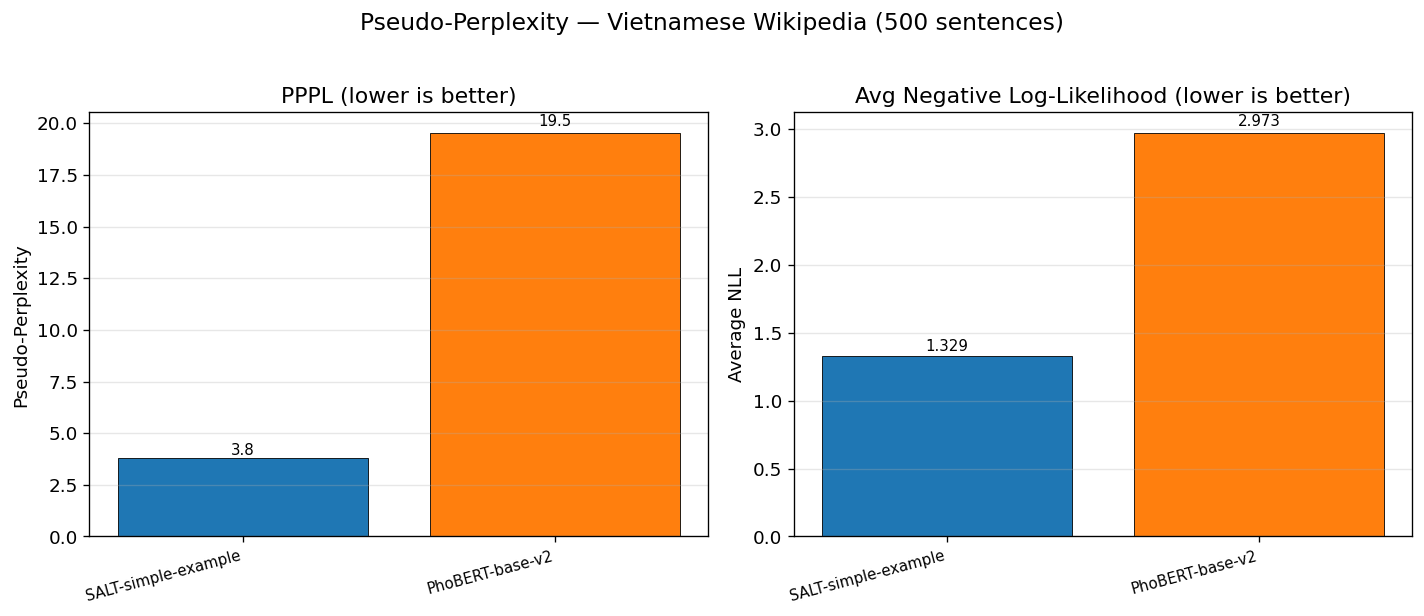

In [8]:
models = list(pppl_results.keys())
pppls = [pppl_results[m].get('pppl', pppl_results[m].get('pppl', 0)) for m in models]
nlls = [pppl_results[m].get('avg_nll', 0) for m in models]
colors = plt.cm.tab10.colors[:len(models)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
bars = axes[0].bar(range(len(models)), pppls, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_xticks(range(len(models)))
axes[0].set_xticklabels(models, rotation=15, ha='right', fontsize=9)
axes[0].set_ylabel('Pseudo-Perplexity')
axes[0].set_title('PPPL (lower is better)')
for bar, val in zip(bars, pppls):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=9)
axes[0].grid(True, axis='y', alpha=0.3)

bars = axes[1].bar(range(len(models)), nlls, color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_xticks(range(len(models)))
axes[1].set_xticklabels(models, rotation=15, ha='right', fontsize=9)
axes[1].set_ylabel('Average NLL')
axes[1].set_title('Avg Negative Log-Likelihood (lower is better)')
for bar, val in zip(bars, nlls):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)
axes[1].grid(True, axis='y', alpha=0.3)

fig.suptitle(f'Pseudo-Perplexity — Vietnamese Wikipedia ({len(pppl_texts)} sentences)', fontsize=14, y=1.02)
fig.tight_layout()
plt.savefig(EVAL_DIR / 'plot_pppl.png', dpi=150, bbox_inches='tight')
plt.show()

## Unified downstream runner (Phase 2+)

In [ ]:
# ══ Unified downstream runner: hybrid HP grid + multi-seed + early stopping + segmentation ══
# Every sentence/pair task runs through this one path so all 4 models share an identical
# protocol. Grid runs (LR sweep on the first seed, scored on the VALIDATION split) write to throwaway dirs
# and are NOT recorded; only the final best-LR per-seed runs are saved to seed_{s}/ (canonical,
# so the plotters and the significance cell find them) and appended to RESULTS_JSONL.

GRID_LRS = [2e-5, 3e-5, 5e-5]   # small-task LR grid (NeoBERT Appendix C spirit, adapted)

def _prep_split(tokenizer, split, tokenize_fn, text_fields, spec, train_cap=None, seed=42):
    if train_cap and len(split) > train_cap:
        split = split.shuffle(seed=seed).select(range(train_cap))
    def _tok(batch):
        if spec.get('segment'):
            for f in text_fields:
                if f in batch:
                    batch[f] = maybe_segment(batch[f], spec)
        return tokenize_fn(tokenizer, batch)
    tok = split.map(_tok, batched=True)
    keep = {'input_ids', 'attention_mask', 'token_type_ids', 'labels'}
    return tok.remove_columns([c for c in tok.column_names if c not in keep])

def eval_seq_task(task, dataset, tokenize_fn, num_labels, *, text_fields, metric_for_best,
                  patience=3, max_epochs=10, batch_size=32, grid=True, fixed_lr=2e-5,
                  regression=False, greater=True, train_cap=None):
    compute_fn = compute_regression_metrics if regression else compute_cls_metrics
    summaries = {}
    for model_name in EVAL_MODELS:
        spec = MODEL_SPECS[model_name]
        def run_one(lr, seed, subdir, record):
            if record and already_done(task, model_name, seed):
                prev = [r for r in read_jsonl(RESULTS_JSONL)
                        if r.get('task') == task and r.get('model') == model_name
                        and r.get('seed') == seed]
                if prev:
                    print(f'Skip existing: {task}/{model_name}/seed={seed}')
                    return float(prev[-1].get(metric_for_best, 0))
            set_seed(seed)
            tokenizer, model = load_sequence_model(model_name, num_labels)
            splits = {sk: _prep_split(tokenizer, dataset[sk], tokenize_fn, text_fields, spec,
                                      train_cap=(train_cap if sk == 'train' else None), seed=seed)
                      for sk in ['train', 'validation', 'test']}
            out_dir = ensure_dir(EVAL_DIR / task / model_name.replace('/', '_') / subdir)
            args = TrainingArguments(
                output_dir=str(out_dir), num_train_epochs=max_epochs, learning_rate=lr,
                per_device_train_batch_size=batch_size, per_device_eval_batch_size=batch_size * 2,
                weight_decay=0.01, warmup_ratio=0.1, eval_strategy='epoch', save_strategy='epoch',
                save_total_limit=1, load_best_model_at_end=True, metric_for_best_model=metric_for_best,
                greater_is_better=greater,
                bf16=torch.cuda.is_bf16_supported() if torch.cuda.is_available() else False,
                fp16=(not torch.cuda.is_bf16_supported()) if torch.cuda.is_available() else False,
                tf32=torch.cuda.is_available(), report_to='none', seed=seed, remove_unused_columns=True,
            )
            trainer = Trainer(
                model=model, args=args, train_dataset=splits['train'], eval_dataset=splits['validation'],
                data_collator=DataCollatorWithPadding(tokenizer), processing_class=tokenizer,
                compute_metrics=compute_fn, callbacks=[make_early_stopping(patience)],
            )
            ckpt = get_last_checkpoint(out_dir)
            trainer.train(resume_from_checkpoint=ckpt)
            # grid probes are model-selection runs: score them on validation so the
            # LR choice never sees the test split; only recorded final runs touch test
            pred = trainer.predict(splits['test'] if record else splits['validation'])
            labels = pred.label_ids
            if regression:
                preds = np.asarray(pred.predictions).reshape(-1)
                metrics = compute_regression_metrics((preds, labels))
            else:
                preds = np.argmax(pred.predictions, axis=-1)
                metrics = compute_cls_metrics((pred.predictions, labels))
            if record:
                np.savez_compressed(str(out_dir / 'test_preds.npz'),
                                    preds=np.asarray(preds), labels=np.asarray(labels))
                write_json(out_dir / 'training_log.json', trainer.state.log_history)
                save_result(task, model_name, seed, {**metrics, 'lr': lr})
            del trainer, model
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            return float(metrics[metric_for_best])
        # hybrid grid: sweep LRs on the first seed (not recorded), then run best on all seeds
        if grid and len(GRID_LRS) > 1:
            scored = [(run_one(lr, SEEDS[0], f'grid_lr{lr}', False), lr) for lr in GRID_LRS]
            best_lr = (max if greater else min)(scored)[1]
        else:
            best_lr = fixed_lr
        vals = [run_one(best_lr, s, f'seed_{s}', True) for s in SEEDS]
        summaries[model_name] = {'best_lr': best_lr, 'mean': float(np.mean(vals)), 'std': float(np.std(vals))}
        print(f'[{task}/{model_name}] best_lr={best_lr} {metric_for_best}={np.mean(vals):.4f}±{np.std(vals):.4f}')
    write_json(EVAL_DIR / task / 'grid_summary.json', summaries)
    return summaries


## UIT-VSFC Sentiment

In [9]:
raw_vsfc = load_dataset('tridm/UIT-VSFC')
if 'validation' not in raw_vsfc and 'dev' in raw_vsfc:
    raw_vsfc['validation'] = raw_vsfc['dev']
text_col = next(c for c in ['Sentence', 'sentence', 'text'] if c in raw_vsfc['train'].column_names)
label_col = next(c for c in ['Encoded_sentiment', 'sentiment', 'label'] if c in raw_vsfc['train'].column_names)

def clean_vsfc(split):
    return Dataset.from_dict({'text': [str(x) for x in split[text_col]], 'labels': [int(x) for x in split[label_col]]})

vsfc = DatasetDict({k: clean_vsfc(raw_vsfc[k]) for k in ['train', 'validation', 'test']})

def tokenize_vsfc(tokenizer, batch):
    return tokenizer(batch['text'], truncation=True, max_length=256)

eval_seq_task('UIT-VSFC', vsfc, tokenize_vsfc, 3, text_fields=['text'],
              metric_for_best='f1_weighted', grid=True, patience=3, max_epochs=10, batch_size=16)

train.json:   0%|          | 0.00/2.69M [00:00<?, ?B/s]

valid.json:   0%|          | 0.00/367k [00:00<?, ?B/s]

test.json:   0%|          | 0.00/744k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/11426 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1583 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved result: {'task': 'UIT-VSFC', 'model': 'PhoBERT-base-v2', 'seed': 456, 'loss': 0.2689656913280487, 'accuracy': 0.9384080859128238, 'f1_macro': 0.8381901051123745, 'f1_weighted': 0.9362044938663324}


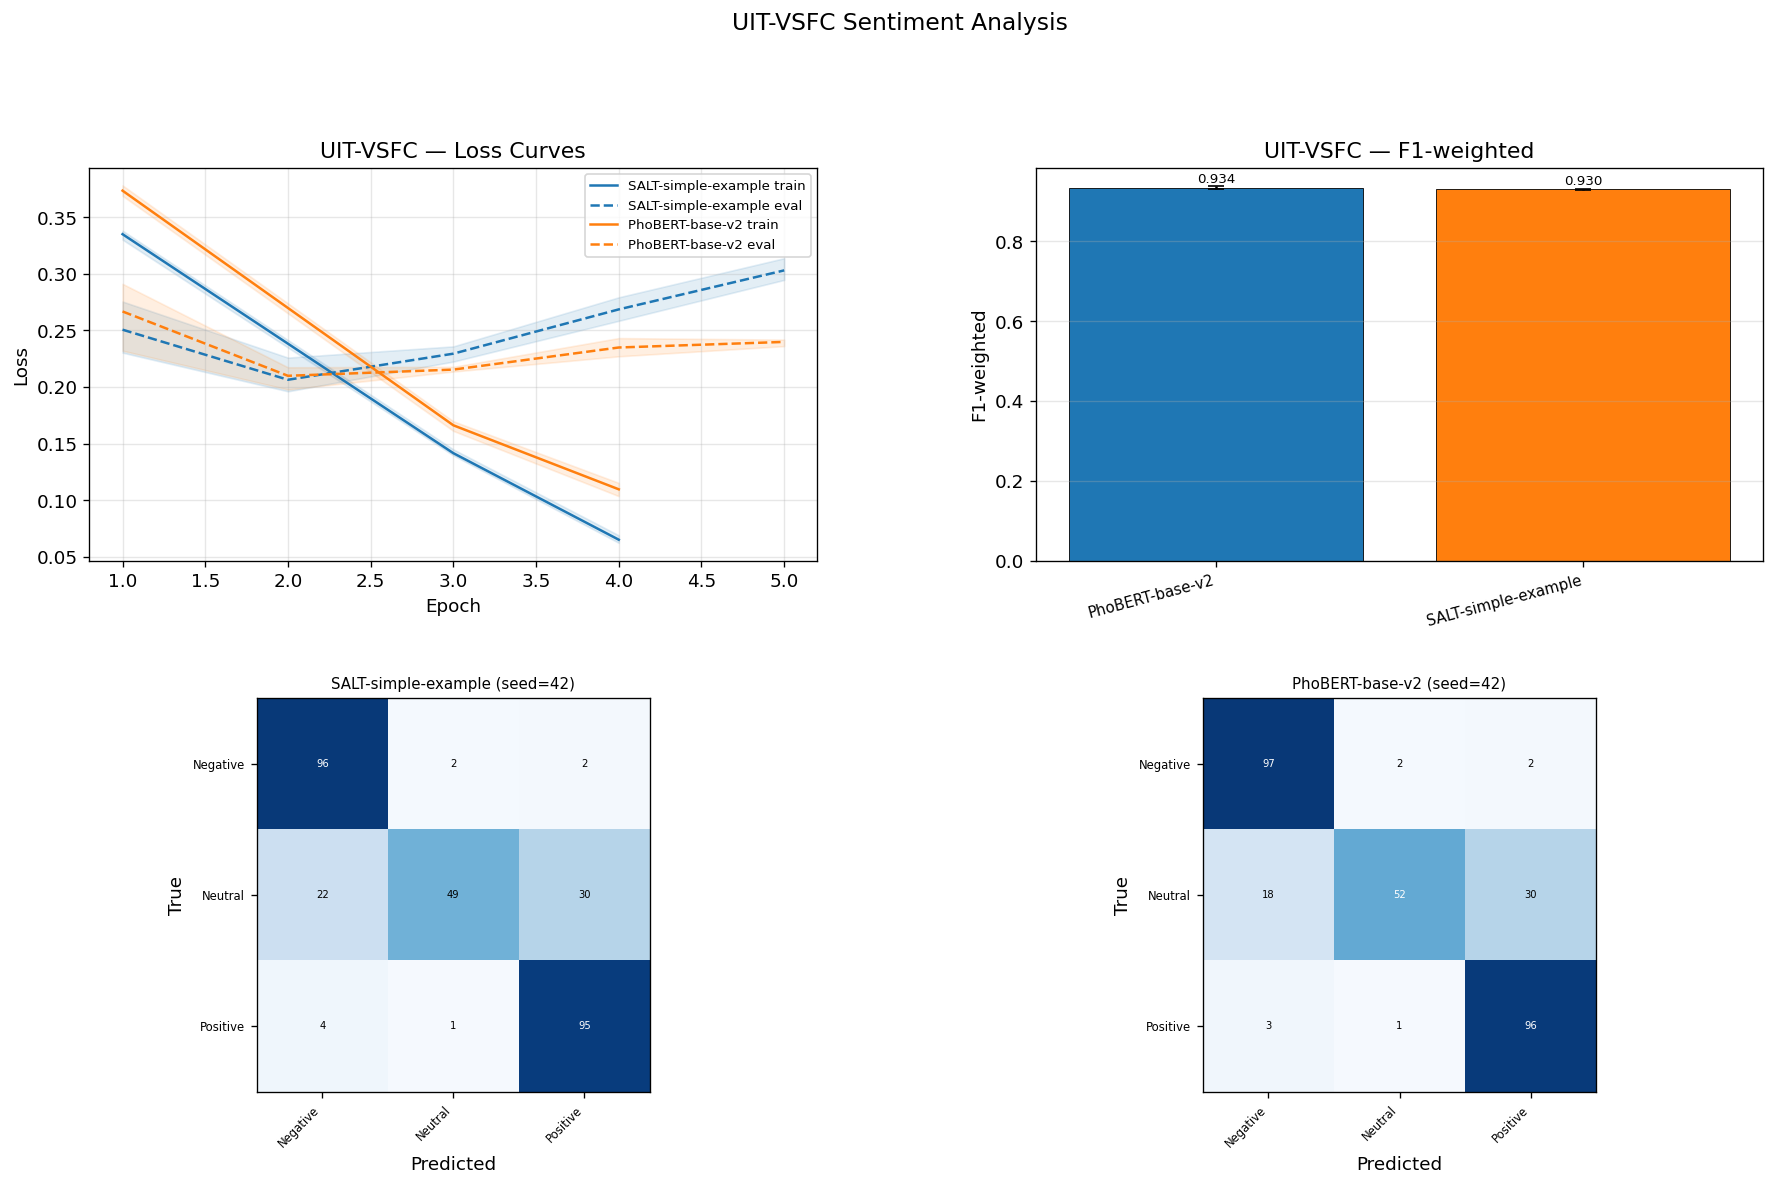

In [10]:
VSFC_CLASSES = ['Negative', 'Neutral', 'Positive']
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)
ax_loss = fig.add_subplot(gs[0, 0])
ax_bar = fig.add_subplot(gs[0, 1])
ax_cm = [fig.add_subplot(gs[1, i]) for i in range(2)]
plot_loss_curves('UIT-VSFC', EVAL_MODELS, SEEDS, ax=ax_loss)
plot_model_comparison('UIT-VSFC', 'f1_weighted', 'F1-weighted', ax=ax_bar)
plot_confusion_mat('UIT-VSFC', EVAL_MODELS[:2], SEEDS[0], VSFC_CLASSES, ax_list=ax_cm[:len(EVAL_MODELS)])
fig.suptitle('UIT-VSFC Sentiment Analysis', fontsize=14, y=1.01)
plt.savefig(EVAL_DIR / 'plot_vsfc.png', dpi=150, bbox_inches='tight')
plt.show()

## XNLI Vietnamese

In [ ]:
raw_xnli = load_dataset('xnli', 'vi')

def clean_xnli(split):
    return Dataset.from_dict({
        'premise': [str(x) for x in split['premise']],
        'hypothesis': [str(x) for x in split['hypothesis']],
        'labels': [int(x) for x in split['label']],
    })

xnli = DatasetDict({k: clean_xnli(raw_xnli[k]) for k in ['train', 'validation', 'test']})

def tokenize_xnli(tokenizer, batch):
    return tokenizer(batch['premise'], batch['hypothesis'], truncation=True, max_length=256)

eval_seq_task('XNLI-vi', xnli, tokenize_xnli, 3, text_fields=['premise', 'hypothesis'],
              metric_for_best='accuracy', grid=False, fixed_lr=2e-5, patience=2,
              max_epochs=5, batch_size=32, train_cap=100000)

In [ ]:
XNLI_CLASSES = ['Entailment', 'Neutral', 'Contradiction']
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)
ax_loss = fig.add_subplot(gs[0, 0])
ax_bar = fig.add_subplot(gs[0, 1])
ax_cm = [fig.add_subplot(gs[1, i]) for i in range(2)]
plot_loss_curves('XNLI-vi', EVAL_MODELS, SEEDS, ax=ax_loss)
plot_model_comparison('XNLI-vi', 'accuracy', 'Accuracy', ax=ax_bar)
plot_confusion_mat('XNLI-vi', EVAL_MODELS[:2], SEEDS[0], XNLI_CLASSES, ax_list=ax_cm[:len(EVAL_MODELS)])
fig.suptitle('XNLI Vietnamese — Natural Language Inference', fontsize=14, y=1.01)
plt.savefig(EVAL_DIR / 'plot_xnli.png', dpi=150, bbox_inches='tight')
plt.show()

## UIT-VSMEC Emotion

In [ ]:
raw_vsmec = load_dataset('tridm/UIT-VSMEC')
EMOTION_LABELS = ['Other', 'Enjoyment', 'Sadness', 'Anger', 'Surprise', 'Fear', 'Disgust']
emotion2id = {e: i for i, e in enumerate(EMOTION_LABELS)}

def clean_vsmec(split):
    return Dataset.from_dict({
        'text': [str(x) for x in split['Sentence']],
        'labels': [emotion2id[str(x)] for x in split['Emotion']],
    })

vsmec = DatasetDict({k: clean_vsmec(raw_vsmec[k]) for k in ['train', 'validation', 'test']})

def tokenize_vsmec(tokenizer, batch):
    return tokenizer(batch['text'], truncation=True, max_length=256)

eval_seq_task('UIT-VSMEC', vsmec, tokenize_vsmec, 7, text_fields=['text'],
              metric_for_best='f1_macro', grid=True, patience=3, max_epochs=10, batch_size=16)

In [ ]:
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.3)
ax_loss = fig.add_subplot(gs[0, 0])
ax_bar = fig.add_subplot(gs[0, 1])
ax_cm = fig.add_subplot(gs[0, 2])
ax_f1 = fig.add_subplot(gs[1, :])
plot_loss_curves('UIT-VSMEC', EVAL_MODELS, SEEDS, ax=ax_loss)
plot_model_comparison('UIT-VSMEC', 'f1_macro', 'F1-macro', ax=ax_bar)
plot_confusion_mat('UIT-VSMEC', [EVAL_MODELS[0]], SEEDS[0], EMOTION_LABELS, ax_list=[ax_cm])
plot_per_class_f1('UIT-VSMEC', EVAL_MODELS, SEEDS[0], EMOTION_LABELS, ax=ax_f1)
fig.suptitle('UIT-VSMEC Emotion Classification (7 classes)', fontsize=14, y=1.01)
plt.savefig(EVAL_DIR / 'plot_vsmec.png', dpi=150, bbox_inches='tight')
plt.show()

## UIT-ViCTSD Toxicity

In [ ]:
raw_victsd = load_dataset('tarudesu/ViCTSD')

def clean_victsd(split):
    return Dataset.from_dict({
        'text': [str(x) for x in split['Comment']],
        'labels': [int(x) for x in split['Toxicity']],
    })

victsd = DatasetDict({k: clean_victsd(raw_victsd[k]) for k in ['train', 'validation', 'test']})

def tokenize_victsd(tokenizer, batch):
    return tokenizer(batch['text'], truncation=True, max_length=256)

eval_seq_task('UIT-ViCTSD', victsd, tokenize_victsd, 2, text_fields=['text'],
              metric_for_best='f1_macro', grid=True, patience=3, max_epochs=10, batch_size=16)

In [ ]:
TOXICITY_CLASSES = ['Non-toxic', 'Toxic']
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)
ax_loss = fig.add_subplot(gs[0, 0])
ax_bar = fig.add_subplot(gs[0, 1])
ax_cm = [fig.add_subplot(gs[1, i]) for i in range(2)]
plot_loss_curves('UIT-ViCTSD', EVAL_MODELS, SEEDS, ax=ax_loss)
plot_model_comparison('UIT-ViCTSD', 'f1_macro', 'F1-macro', ax=ax_bar)
plot_confusion_mat('UIT-ViCTSD', EVAL_MODELS[:2], SEEDS[0], TOXICITY_CLASSES, ax_list=ax_cm[:len(EVAL_MODELS)])
fig.suptitle('UIT-ViCTSD Toxicity Detection (binary)', fontsize=14, y=1.01)
plt.savefig(EVAL_DIR / 'plot_victsd.png', dpi=150, bbox_inches='tight')
plt.show()

## UD-VTB POS Tagging

In [ ]:
import urllib.request
from datasets import ClassLabel, Sequence, Features, Value

UPOS_TAGS = ["NOUN", "PUNCT", "ADP", "NUM", "SYM", "SCONJ", "ADJ", "PART", "DET", "CCONJ", "PROPN", "PRON", "X", "_", "ADV", "INTJ", "VERB", "AUX"]
upos_cl = ClassLabel(names=UPOS_TAGS)

def parse_conllu(path):
    sentences = []
    tokens, upos = [], []
    with open(path, encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                if tokens:
                    sentences.append({'tokens': tokens, 'upos': upos})
                    tokens, upos = [], []
            elif line.startswith('#'):
                continue
            else:
                fields = line.split('\t')
                if '-' in fields[0] or '.' in fields[0]:
                    continue
                tokens.append(fields[1])
                upos.append(upos_cl.str2int(fields[3]))
    if tokens:
        sentences.append({'tokens': tokens, 'upos': upos})
    return sentences

UD_BASE = 'https://raw.githubusercontent.com/UniversalDependencies/UD_Vietnamese-VTB/master'
ud_splits = {}
for split, fname in [('train', 'vi_vtb-ud-train.conllu'), ('validation', 'vi_vtb-ud-dev.conllu'), ('test', 'vi_vtb-ud-test.conllu')]:
    local = EVAL_DIR / fname
    if not local.exists():
        urllib.request.urlretrieve(f'{UD_BASE}/{fname}', local)
        print(f'Downloaded {fname}')
    ud_splits[split] = parse_conllu(local)

ud_features = Features({'tokens': Sequence(Value('string')), 'upos': Sequence(upos_cl)})
ud_pos = DatasetDict({
    split: Dataset.from_list(rows, features=ud_features)
    for split, rows in ud_splits.items()
})
NUM_UPOS = upos_cl.num_classes
upos_names = UPOS_TAGS
print(f'UPOS classes: {NUM_UPOS}, splits: {[f"{k}={len(v)}" for k, v in ud_pos.items()]}')

for model_name in EVAL_MODELS:
    def _pos(lr, seed, subdir, record, _m=model_name):
        return train_eval_token_classification('UD-VTB-POS', _m, ud_pos, num_labels=NUM_UPOS,
                                               label_col='upos', epochs=15, lr=lr, batch_size=16,
                                               seed=seed, metric_for_best='f1_macro', patience=5,
                                               subdir=subdir, record=record)['f1_macro']
    scored = [(_pos(lr, SEEDS[0], f'grid_lr{lr}', False), lr) for lr in GRID_LRS]
    best_lr = max(scored)[1]
    vals = [_pos(best_lr, sd, f'seed_{sd}', True) for sd in SEEDS]
    print(f'[UD-VTB-POS/{model_name}] best_lr={best_lr} f1_macro={np.mean(vals):.4f}±{np.std(vals):.4f}')

In [ ]:
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)
ax_loss = fig.add_subplot(gs[0, 0])
ax_bar = fig.add_subplot(gs[0, 1])
ax_f1 = fig.add_subplot(gs[1, :])
plot_loss_curves('UD-VTB-POS', EVAL_MODELS, SEEDS, ax=ax_loss)
plot_model_comparison('UD-VTB-POS', 'f1_macro', 'F1-macro', ax=ax_bar)
plot_per_class_f1('UD-VTB-POS', EVAL_MODELS, SEEDS[0], upos_names, ax=ax_f1)
fig.suptitle('UD-VTB POS Tagging (UPOS)', fontsize=14, y=1.01)
plt.savefig(EVAL_DIR / 'plot_pos.png', dpi=150, bbox_inches='tight')
plt.show()

## MRC — UIT-ViQuAD 2.0

Machine Reading Comprehension (extractive QA): given a context paragraph and question, predict the answer span. Evaluates deep language understanding beyond classification — the model must locate precise token boundaries. Uses SQuAD F1 and Exact Match metrics.

Only answerable rows are used (is_impossible=False). Fast tokenizer required for offset mapping + span alignment. PhoBERT max_length capped to 256 (max_position_embeddings=258).

In [ ]:
from bisect import bisect_right

squad_metric = evaluate.load('squad')

MRC_MAX_LEN = 384
MRC_LR = 2e-5
MRC_EPOCHS = 5
MRC_BS = 8
MRC_TRAIN_CAP = None  # full ViQuAD train (was 4000 -> severe underfit)
MRC_EVAL_CAP = 500


def _first_answer(ex):
    if ex.get('is_impossible', False):
        return None
    a = ex['answers']
    if not isinstance(a, dict) or not a.get('text'):
        return None
    t = a['text'][0]
    if t is None:
        return None
    t = str(t).strip()
    return (t, int(a['answer_start'][0])) if t else None


def _build_qa_rows(split_ds, tokenizer, cap, max_len, model_vocab=None, seed=42, spec=None):
    """Tokenize QA pairs, align char-span to token-span via offset_mapping.
    Requires fast tokenizer. Filters OOB token IDs for vocab-mismatched models."""
    if not tokenizer.is_fast:
        print(f'  {type(tokenizer).__name__}: slow tokenizer, skipping MRC')
        return Dataset.from_list([])
    random.seed(seed)
    idxs = list(range(len(split_ds)))
    random.shuffle(idxs)
    rows, drops = [], {'no_answer': 0, 'span_not_found': 0, 'truncated': 0}
    for j in idxs:
        if cap and len(rows) >= cap:
            break
        ex = split_ds[j]
        fa = _first_answer(ex)
        if fa is None:
            drops['no_answer'] += 1
            continue
        text, char_start = fa
        char_end = char_start + len(text)
        question, context = ex['question'], ex['context']
        if spec and spec.get('segment'):
            question = maybe_segment([question], spec)[0]
            ctx_seg = maybe_segment([context], spec)[0]
            txt_seg = maybe_segment([text], spec)[0]
            idx = ctx_seg.find(txt_seg)
            if idx >= 0:
                context, text, char_start = ctx_seg, txt_seg, idx
                char_end = idx + len(txt_seg)
            else:
                drops['span_not_found'] += 1
                continue
        enc = tokenizer(question, context, truncation='only_second',
                        max_length=max_len, return_offsets_mapping=True,
                        padding='max_length', return_token_type_ids=False)
        offsets = enc.pop('offset_mapping')
        seq_ids = enc.sequence_ids()
        ctx_mask = [int(seq_ids[ti] == 1) for ti in range(len(offsets))]
        start_t = end_t = None
        for ti, (cs, ce) in enumerate(offsets):
            if seq_ids[ti] != 1 or cs is None or ce is None:
                continue
            if cs <= char_start < ce and start_t is None:
                start_t = ti
            if cs < char_end <= ce:
                end_t = ti
        if start_t is None or end_t is None or end_t < start_t:
            ctx_end = max((ti for ti, sid in enumerate(seq_ids) if sid == 1), default=-1)
            if ctx_end >= 0 and char_end > offsets[ctx_end][1]:
                drops['truncated'] += 1
            else:
                drops['span_not_found'] += 1
            continue
        enc['start_positions'] = start_t
        enc['end_positions'] = end_t
        enc['context_token_mask'] = ctx_mask
        enc['example_id'] = str(ex.get('id', f'row{j}'))
        enc['answers'] = {'text': [text], 'answer_start': [char_start]}
        rows.append(enc)
    if model_vocab and rows:
        before = len(rows)
        rows = [r for r in rows if max(r['input_ids']) < model_vocab]
        if len(rows) < before:
            print(f'  Filtered {before - len(rows)} OOB-vocab rows')
    print(f'  QA rows: {len(rows)} kept, drops={drops}')
    return Dataset.from_list(rows)


def _squad_post_eval(model, tokenizer, eval_ds, device, batch_size=16):
    """Predict spans constrained to context tokens, compute SQuAD F1/EM."""
    model.eval()
    preds, refs = [], []
    n = len(eval_ds)
    for batch_start in range(0, n, batch_size):
        batch_end = min(batch_start + batch_size, n)
        batch_examples = [eval_ds[i] for i in range(batch_start, batch_end)]
        input_ids = torch.tensor([ex['input_ids'] for ex in batch_examples]).to(device)
        attn_mask = torch.tensor([ex['attention_mask'] for ex in batch_examples]).to(device)
        with torch.no_grad():
            out = model(input_ids=input_ids, attention_mask=attn_mask)
        batch_sl = out['start_logits'].float().cpu()
        batch_el = out['end_logits'].float().cpu()
        for bi, ex in enumerate(batch_examples):
            sl, el = batch_sl[bi], batch_el[bi]
            ctx_mask = ex.get('context_token_mask', [1] * len(ex['input_ids']))
            valid_idx = [j for j, ok in enumerate(ctx_mask) if ok]
            if not valid_idx:
                pred_text = ''
            else:
                best = None
                for idx_i, si0 in enumerate(valid_idx):
                    end_bound = bisect_right(valid_idx, si0 + 30)
                    for ei0 in valid_idx[idx_i:end_bound]:
                        score = float(sl[si0] + el[ei0])
                        if best is None or score > best[0]:
                            best = (score, si0, ei0)
                _, si, ei = best
                pred_text = tokenizer.decode(ex['input_ids'][si:ei + 1], skip_special_tokens=True)
            preds.append({'prediction_text': pred_text, 'id': ex['example_id']})
            refs.append({'id': ex['example_id'], 'answers': ex['answers']})
    return squad_metric.compute(predictions=preds, references=refs)


def train_eval_mrc(task, model_name, train_split, val_split, test_split, seed):
    if already_done(task, model_name, seed):
        print(f'Skip existing: {task}/{model_name}/seed={seed}')
        return
    set_seed(seed)
    spec = MODEL_SPECS[model_name]
    path = model_path_from_spec(spec)
    tokenizer = AutoTokenizer.from_pretrained(path, trust_remote_code=True, use_fast=True)
    if not tokenizer.is_fast:
        print(f'  {model_name}: slow tokenizer, skipping MRC')
        return
    config = AutoConfig.from_pretrained(path, trust_remote_code=True)
    model_vocab = getattr(config, 'vocab_size', None)
    max_pos = getattr(config, 'max_position_embeddings', 512)
    effective_max = min(MRC_MAX_LEN, max(64, max_pos - 2))
    print(f'{model_name} seed={seed}: vocab={model_vocab} max_pos={max_pos} eff_max={effective_max}')

    if spec['kind'] == 'neobert':
        base = load_model_safe(path, model_cls=AutoModelForMaskedLM, device='cpu')
        print('Base embedding fp:', embedding_fingerprint(base))
        model = NeoBERTQuestionAnswering(base).to(DEVICE)
    else:
        model = AutoModelForQuestionAnswering.from_pretrained(
            path, trust_remote_code=True).to(DEVICE)

    tr = _build_qa_rows(train_split, tokenizer, MRC_TRAIN_CAP, effective_max, model_vocab, seed, spec)
    ev_val = _build_qa_rows(val_split, tokenizer, MRC_EVAL_CAP, effective_max, model_vocab, seed, spec)
    ev_test = _build_qa_rows(test_split, tokenizer, MRC_EVAL_CAP, effective_max, model_vocab, seed, spec)
    if len(tr) < 50 or len(ev_val) < 20 or len(ev_test) < 10:
        print(f'  Too few QA rows — skip')
        del model; gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        return

    train_cols = [c for c in tr.column_names
                  if c not in ('input_ids', 'attention_mask', 'start_positions', 'end_positions')]
    tr_clean = tr.remove_columns(train_cols) if train_cols else tr

    output_dir = EVAL_DIR / task / model_name.replace('/', '_') / f'seed_{seed}'
    args = TrainingArguments(
        output_dir=str(output_dir), num_train_epochs=MRC_EPOCHS, learning_rate=MRC_LR,
        per_device_train_batch_size=MRC_BS, per_device_eval_batch_size=MRC_BS,
        weight_decay=0.01, warmup_ratio=0.1, eval_strategy='epoch',
        save_strategy='epoch', save_total_limit=1,
        load_best_model_at_end=True, metric_for_best_model='loss', greater_is_better=False,
        bf16=torch.cuda.is_bf16_supported() if torch.cuda.is_available() else False,
        fp16=not torch.cuda.is_bf16_supported() if torch.cuda.is_available() else False,
        tf32=torch.cuda.is_available(), report_to='none', seed=seed,
        remove_unused_columns=False,
    )
    ev_val_clean = ev_val.remove_columns([c for c in ev_val.column_names
                                          if c not in ('input_ids', 'attention_mask', 'start_positions', 'end_positions')])
    trainer = Trainer(
        model=model, args=args, train_dataset=tr_clean, eval_dataset=ev_val_clean,
        processing_class=tokenizer, data_collator=DefaultDataCollator(),
        callbacks=[make_early_stopping(2)],
    )
    checkpoint = get_last_checkpoint(output_dir)
    if checkpoint:
        print('Resuming MRC checkpoint:', checkpoint)
    trainer.train(resume_from_checkpoint=checkpoint)
    write_json(output_dir / 'training_log.json', trainer.state.log_history)
    metrics = _squad_post_eval(model, tokenizer, ev_test, DEVICE)
    save_result(task, model_name, seed, {
        'f1': float(metrics['f1']),
        'exact_match': float(metrics['exact_match']),
    })
    print(f'  {model_name} seed={seed}: F1={metrics["f1"]:.2f}  EM={metrics["exact_match"]:.2f}')
    del trainer, model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


print('Loading UIT-ViQuAD 2.0...')
qa_ds = load_dataset('taidng/UIT-ViQuAD2.0')
qa_train = qa_ds['train']
_qa_eval = qa_ds['validation'] if 'validation' in qa_ds else qa_ds['test']
_qa_sp = _qa_eval.train_test_split(test_size=0.5, seed=42)
qa_val, qa_test = _qa_sp['train'], _qa_sp['test']
print(f'  Train: {len(qa_train)}, Val: {len(qa_val)}, Test: {len(qa_test)}')

for model_name in EVAL_MODELS:
    for seed in SEEDS:
        train_eval_mrc('MRC-ViQuAD', model_name, qa_train, qa_val, qa_test, seed)

In [ ]:
fig = plt.figure(figsize=(18, 5))
gs = fig.add_gridspec(1, 3, wspace=0.3)
ax_loss = fig.add_subplot(gs[0, 0])
ax_f1 = fig.add_subplot(gs[0, 1])
ax_em = fig.add_subplot(gs[0, 2])
plot_loss_curves('MRC-ViQuAD', EVAL_MODELS, SEEDS, ax=ax_loss)
plot_model_comparison('MRC-ViQuAD', 'f1', 'SQuAD F1', ax=ax_f1)
plot_model_comparison('MRC-ViQuAD', 'exact_match', 'Exact Match', ax=ax_em)
fig.suptitle('MRC — UIT-ViQuAD 2.0 (Extractive QA)', fontsize=14, y=1.02)
plt.savefig(EVAL_DIR / 'plot_mrc.png', dpi=150, bbox_inches='tight')
plt.show()

## STS — Semantic Textual Similarity (regression, covers GLUE STS-B)

In [ ]:
# Vietnamese STS-B analog. Regression head (num_labels=1, MSE); report Spearman.
def _load_sts():
    for ds_id in ['GreenNode/stsbenchmark-sts-vn', 'GreenNode/sickr-sts-vn']:
        try:
            raw = load_dataset(ds_id)
            print('Loaded STS:', ds_id, {k: len(v) for k, v in raw.items()})
            return raw, ds_id
        except Exception as exc:
            print('STS load failed', ds_id, exc)
    raise RuntimeError('No Vietnamese STS dataset available')

raw_sts, STS_ID = _load_sts()
_cols = raw_sts[list(raw_sts.keys())[0]].column_names
s1 = next(c for c in ['sentence1', 'sentence_1', 'sent1', 'premise'] if c in _cols)
s2 = next(c for c in ['sentence2', 'sentence_2', 'sent2', 'hypothesis'] if c in _cols)
sc = next(c for c in ['score', 'similarity_score', 'label', 'sim'] if c in _cols)
_smax = max(float(x) for x in raw_sts[list(raw_sts.keys())[0]][sc])  # 5.0 (STS-B) or 1.0
def _clean_sts(split):
    return Dataset.from_dict({
        'sentence1': [str(a) for a in split[s1]],
        'sentence2': [str(b) for b in split[s2]],
        'labels': [float(x) / _smax for x in split[sc]],  # normalize to [0,1]; Spearman is scale-invariant
    })
def _sts_splits(raw):
    keys = set(raw.keys())
    train = raw['train'] if 'train' in keys else raw[list(keys)[0]]
    val = raw['validation'] if 'validation' in keys else (raw['dev'] if 'dev' in keys else None)
    test = raw['test'] if 'test' in keys else None
    if val is None:
        sp = train.train_test_split(test_size=0.1, seed=42); train, val = sp['train'], sp['test']
    if test is None:
        sp = val.train_test_split(test_size=0.5, seed=42); val, test = sp['train'], sp['test']
    return DatasetDict({'train': train, 'validation': val, 'test': test})
sts = _sts_splits(raw_sts).map(lambda b: b)  # materialize
sts = DatasetDict({k: _clean_sts(sts[k]) for k in ['train', 'validation', 'test']})
def tokenize_sts(tokenizer, batch):
    return tokenizer(batch['sentence1'], batch['sentence2'], truncation=True, max_length=128)
eval_seq_task('STS', sts, tokenize_sts, 1, text_fields=['sentence1', 'sentence2'],
              metric_for_best='spearman', regression=True, grid=True, patience=3,
              max_epochs=10, batch_size=16, greater=True)


## ViANLI — Native Vietnamese NLI (covers MNLI/RTE; native vs translated XNLI)

In [ ]:
raw_vianli = load_dataset('uitnlp/ViANLI')
print('ViANLI splits:', {k: len(v) for k, v in raw_vianli.items()})
_vcols = raw_vianli[list(raw_vianli.keys())[0]].column_names
print('ViANLI columns:', _vcols)
_pre = next(c for c in ['premise', 'sentence1', 'context'] if c in _vcols)
_hyp = next(c for c in ['hypothesis', 'sentence2'] if c in _vcols)
_lab = next(c for c in ['label', 'gold_label', 'labels'] if c in _vcols)
_NLI_MAP = {'entailment': 0, 'neutral': 1, 'contradiction': 2,
            'e': 0, 'n': 1, 'c': 2, '0': 0, '1': 1, '2': 2}
def _enc_nli(v):
    if isinstance(v, int):
        return v
    return _NLI_MAP[str(v).strip().lower()]
def _clean_vianli(split):
    return Dataset.from_dict({
        'premise': [str(a) for a in split[_pre]],
        'hypothesis': [str(b) for b in split[_hyp]],
        'labels': [_enc_nli(x) for x in split[_lab]],
    })
def _nli_splits(raw):
    keys = set(raw.keys())
    train = raw['train']
    val = raw['validation'] if 'validation' in keys else raw.get('dev')
    test = raw['test'] if 'test' in keys else None
    if val is None:
        sp = train.train_test_split(test_size=0.1, seed=42); train, val = sp['train'], sp['test']
    if test is None:
        sp = val.train_test_split(test_size=0.5, seed=42); val, test = sp['train'], sp['test']
    return DatasetDict({'train': train, 'validation': val, 'test': test})
vianli = _nli_splits(raw_vianli)
vianli = DatasetDict({k: _clean_vianli(vianli[k]) for k in ['train', 'validation', 'test']})
def tokenize_vianli(tokenizer, batch):
    return tokenizer(batch['premise'], batch['hypothesis'], truncation=True, max_length=256)
eval_seq_task('ViANLI', vianli, tokenize_vianli, 3, text_fields=['premise', 'hypothesis'],
              metric_for_best='f1_macro', grid=True, patience=3, max_epochs=10, batch_size=16)


## QNLI — derived from ViQuAD (covers GLUE QNLI)

In [ ]:
# QNLI built GLUE-style from UIT-ViQuAD2.0: (question, sentence)->entailment/not_entailment.
import re as _re
import random as _rnd
QNLI_DIR = ensure_dir(PROJECT_ROOT / 'datasets' / 'qnli_from_viquad')
def _split_sentences(text):
    parts = _re.split(r'(?<=[.!?…])\s+', str(text).strip())
    return [p for p in parts if p.strip()]
def _derive_qnli(split, seed=42):
    rng = _rnd.Random(seed)
    rows = {'question': [], 'sentence': [], 'labels': []}
    for ex in split:
        q, ctx = ex.get('question'), ex.get('context')
        ans = ex.get('answers') or {}
        starts = ans.get('answer_start') or []
        if not q or not ctx or not starts:
            continue
        sents = _split_sentences(ctx)
        if len(sents) < 2:
            continue
        spans, off = [], 0
        for s in sents:
            i = ctx.find(s, off); i = i if i >= 0 else off
            spans.append((i, i + len(s))); off = i + len(s)
        a0 = int(starts[0]); pos = next((k for k, (a, b) in enumerate(spans) if a <= a0 < b), None)
        if pos is None:
            continue
        rows['question'].append(q); rows['sentence'].append(sents[pos]); rows['labels'].append(1)
        neg = rng.choice([k for k in range(len(sents)) if k != pos])
        rows['question'].append(q); rows['sentence'].append(sents[neg]); rows['labels'].append(0)
    return Dataset.from_dict(rows)
if (QNLI_DIR / 'dataset_dict.json').exists():
    qnli = DatasetDict.load_from_disk(str(QNLI_DIR))
else:
    qa = load_dataset('taidng/UIT-ViQuAD2.0')
    tr = _derive_qnli(qa['train'])
    va_raw = qa['validation'] if 'validation' in qa else qa['train']
    vt = _derive_qnli(va_raw)
    sp = vt.train_test_split(test_size=0.5, seed=42)
    qnli = DatasetDict({'train': tr, 'validation': sp['train'], 'test': sp['test']})
    qnli.save_to_disk(str(QNLI_DIR))
print('QNLI:', {k: len(v) for k, v in qnli.items()},
      '| balance(train):', float(np.mean(qnli['train']['labels'])))
def tokenize_qnli(tokenizer, batch):
    return tokenizer(batch['question'], batch['sentence'], truncation=True, max_length=256)
eval_seq_task('QNLI', qnli, tokenize_qnli, 2, text_fields=['question', 'sentence'],
              metric_for_best='accuracy', grid=False, fixed_lr=2e-5, patience=2,
              max_epochs=5, batch_size=32, train_cap=100000)


In [ ]:
rows = read_jsonl(RESULTS_JSONL)
summary = pd.DataFrame(rows)
if not summary.empty:
    summary.to_csv(SUMMARY_CSV, index=False)
    display(summary)
    metric_cols = [c for c in ['accuracy', 'f1_macro', 'f1_weighted', 'f1', 'exact_match']
                   if c in summary.columns]
    agg = summary.groupby(['task', 'model'])[metric_cols].agg(['mean', 'std'])
    display(agg)
    for task in summary['task'].unique():
        task_df = summary[summary['task'] == task]
        printed = False
        for metric in ['f1_macro', 'f1', 'exact_match', 'accuracy', 'pppl']:
            if metric not in task_df.columns or task_df[metric].isna().all():
                continue
            ascending = metric == 'pppl'
            best = task_df.groupby('model')[metric].mean().sort_values(ascending=ascending)
            prefix = '\n' if not printed else ''
            print(f'{prefix}{task} — {metric} ranking:')
            for model, score in best.items():
                print(f'  {model}: {score:.4f}')
            printed = True
print('Saved summary:', SUMMARY_CSV)

## Statistical summary, significance & NeoBERT task-type coverage

In [ ]:
# Thesis-grade reporting: per-task mean±std + bootstrap 95% CI over seeds, paired-bootstrap
# significance SALT3 vs each baseline (on the seed-0 test predictions), and the task-type
# coverage table that answers "where is NeoBERT task X?" at the defense.
from collections import defaultdict
from sklearn.metrics import accuracy_score, f1_score

PRIMARY_METRIC = {
    'UIT-VSFC': 'f1_weighted', 'XNLI-vi': 'accuracy', 'UIT-VSMEC': 'f1_macro',
    'UIT-ViCTSD': 'f1_macro', 'UD-VTB-POS': 'f1_macro', 'MRC-ViQuAD': 'f1',
    'STS': 'spearman', 'ViANLI': 'f1_macro', 'QNLI': 'accuracy', 'PPPL': 'pppl',
}
BASE_MODEL = 'SALT3-v5'

def _metric_fn(task):
    mk = PRIMARY_METRIC[task]
    if mk == 'accuracy': return lambda y, p: accuracy_score(y, p)
    if mk == 'f1_macro': return lambda y, p: f1_score(y, p, average='macro')
    if mk == 'f1_weighted': return lambda y, p: f1_score(y, p, average='weighted')
    if mk == 'spearman': return lambda y, p: spearman_pearson(p, y)[0]
    return None  # MRC squad-F1 / PPPL: no aligned-prediction significance

def _seed0_preds(task, model):
    p = EVAL_DIR / task / model.replace('/', '_') / f'seed_{SEEDS[0]}' / 'test_preds.npz'
    if p.exists():
        z = np.load(str(p)); return z['preds'], z['labels']
    return None

vals = defaultdict(lambda: defaultdict(list))
for r in read_jsonl(RESULTS_JSONL):
    t, m = r.get('task'), r.get('model')
    mk = PRIMARY_METRIC.get(t)
    if mk and mk in r:
        vals[t][m].append(float(r[mk]))

report = {}
for task in sorted(vals):
    mk = PRIMARY_METRIC[task]
    lower_better = (mk == 'pppl')
    mf = None if lower_better else _metric_fn(task)
    base_pred = _seed0_preds(task, BASE_MODEL)
    rep = {}
    for model, vlist in vals[task].items():
        lo, hi = bootstrap_ci(vlist)
        e = {'metric': mk, 'mean': float(np.mean(vlist)), 'std': float(np.std(vlist)),
             'ci95': [lo, hi], 'n_seeds': len(vlist)}
        if model != BASE_MODEL and mf is not None and base_pred is not None:
            mp = _seed0_preds(task, model)
            if mp is not None and len(mp[1]) == len(base_pred[1]) and np.array_equal(mp[1], base_pred[1]):
                _, pval, _ = paired_bootstrap_pvalue(base_pred[1], base_pred[0], mp[0], mf)
                e['p_vs_SALT3'] = pval
        rep[model] = e
    report[task] = rep
    print(f'\n=== {task}  ({mk}{" — lower better" if lower_better else ""}) ===')
    for model, e in sorted(rep.items(), key=lambda kv: kv[1]['mean'], reverse=not lower_better):
        sig = ''
        if 'p_vs_SALT3' in e:
            sig = f"  p={e['p_vs_SALT3']:.3f}{'*' if e['p_vs_SALT3'] < 0.05 else ''}"
        print(f"  {model:18s} {e['mean']:.4f} ± {e['std']:.3f}   95%CI[{e['ci95'][0]:.3f}, {e['ci95'][1]:.3f}]{sig}")

write_json(EVAL_DIR / 'eval_results_summary.json', report)

no_sig = [t for t in report if not any('p_vs_SALT3' in e for m, e in report[t].items() if m != BASE_MODEL)]
if no_sig:
    print(f'\nNote: no paired significance for: {", ".join(no_sig)}')
    print('  PPPL: intrinsic metric, no paired test applicable')
    print('  MRC: string-level SQuAD F1 needs per-example scoring for bootstrap')
print('\nSaved:', EVAL_DIR / 'eval_results_summary.json')

print('\n=== NeoBERT task-type coverage (for the defense) ===')
COVERAGE = [
    ('single-sentence cls (SST-2)', 'UIT-VSFC / UIT-VSMEC / UIT-ViCTSD', 'have'),
    ('NLI / entailment (MNLI,RTE)', 'XNLI-vi (translated) + ViANLI (native)', 'covered'),
    ('semantic similarity (STS-B)', 'STS — stsbenchmark-sts-vn (Spearman)', 'added'),
    ('QA->NLI (QNLI)', 'QNLI derived from UIT-ViQuAD2.0', 'added'),
    ('reading comprehension', 'MRC — UIT-ViQuAD2.0 (full data)', 'have'),
    ('sequence labeling', 'UD-VTB POS', 'have'),
    ('acceptability (CoLA)', 'no Vietnamese CoLA; POS partially probes syntax', 'documented gap'),
    ('embedding (MTEB)', 'out of scope; cite VN-MTEB as future work', 'future work'),
]
print(f'  {"NeoBERT task type":32s} {"Vietnamese task":42s} status')
for ttype, vi, status in COVERAGE:
    print(f'  {ttype:32s} {vi:42s} {status}')
